# Tripadvisor Restaurants Analysis in Spain

This project explores restaurant data obtained from Tripadvisor in order to identify patterns related to ratings, popularity, pricing and restaurant categories across Spain.

The analysis focuses on data cleaning, feature engineering and exploratory data analysis (EDA) using Python and Pandas within a modular and reproducible project structure.

The original dataset contains restaurant information from several European countries. In order to improve performance and focus the analysis on a more relevant geographical scope, only restaurants located in Spain are considered for the final working dataset.

The project follows a structured data pipeline:

**raw → clean → features → visualization**

## 1. Data Loading and Initial Inspection

In this initial stage, the required Python libraries are imported and the original dataset is loaded following the modular project structure.

The dataset `tripadvisor_european_restaurants.csv` contains information about restaurants across several European countries. A first inspection of the dataset is performed in order to understand its structure, identify potential inconsistencies, and evaluate the overall quality of the data before applying any transformations.

Since the original dataset is considerably large and includes restaurants from multiple countries, a reduced version containing only restaurants located in Spain is created. This allows for a more focused analysis while also improving performance and usability during the exploratory analysis process.

Initial exploratory checks such as dataset shape, column inspection and general information overview are also performed at this stage.

**Objective:** Validate that the data loading pipeline works correctly and gain an initial understanding of the available variables and dataset structure.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Visualization style
sns.set_theme(context="notebook", style="whitegrid")

# Pandas display options
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
# Project root directory
ROOT = Path.cwd().parent

# Project folders
DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
SRC = ROOT / "src"

# Create folders if they do not exist
for p in [DATA_RAW, DATA_PROCESSED, SRC]:
    p.mkdir(parents=True, exist_ok=True)

# Load original dataset
df = pd.read_csv(DATA_RAW / "tripadvisor_european_restaurants.csv")

# Filter restaurants located in Spain
df2 = df[df["country"] == "Spain"].copy()

# Save reduced dataset for analysis
output_path = DATA_RAW / "tripadvisor_spain.csv"

df2.to_csv(output_path, index=False)
print("NEW CSV saved to:", output_path)


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\romer\\OneDrive\\Escritorio\\Estudios\\Programación\\Master Data Analist y Desarrollo IA\\Python\\Proyecto\\Proyect_Laia_Romera\\data\\raw\\tripadvisor_european_restaurants.csv'

## 2. Initial Data Inspection

Before applying any cleaning or transformation steps, an initial quality check is performed in order to better understand the structure, size and overall condition of the dataset.

This stage helps identify:
- column types,
- missing values,
- potential inconsistencies,
- duplicated records,
- and possible issues that may require cleaning.

In [ ]:
# Load reduced Spain dataset
df = pd.read_csv(DATA_RAW / "tripadvisor_spain.csv")

In [ ]:
# Dataset dimensions
print("Dataset shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.to_list())

# General dataset information
print("\nDataset info:")
df.info()

# Statistical summary
print("\nDescribing:")
display(df.describe())

# Missing values
print("\nMissing values (%):")
display(
    (df.isna().mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

# Duplicate rows
print("\nDuplicated rows:", df.duplicated().sum())

Dataset shape: (157479, 42)

Columns:
['restaurant_link', 'restaurant_name', 'original_location', 'country', 'region', 'province', 'city', 'address', 'latitude', 'longitude', 'claimed', 'awards', 'popularity_detailed', 'popularity_generic', 'top_tags', 'price_level', 'price_range', 'meals', 'cuisines', 'special_diets', 'features', 'vegetarian_friendly', 'vegan_options', 'gluten_free', 'original_open_hours', 'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week', 'avg_rating', 'total_reviews_count', 'default_language', 'reviews_count_in_default_language', 'excellent', 'very_good', 'average', 'poor', 'terrible', 'food', 'service', 'value', 'atmosphere', 'keywords']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 157479 entries, 0 to 157478
Data columns (total 42 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   restaurant_link                    157479 non-null  str    
 1

,latitude,longitude,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere
count,"155,116.00","155,116.00","75,730.00","75,730.00","75,730.00","142,668.00","148,611.00","142,988.00","142,988.00","142,988.00","142,988.00","142,988.00","142,988.00","80,836.00","81,519.00","81,274.00","31,496.00"
mean,39.18,-3.18,6.30,66.49,7.85,3.96,98.70,29.36,16.81,6.87,2.50,1.27,1.92,4.05,4.02,3.94,3.95
std,3.72,4.80,1.00,31.68,2.76,0.76,269.71,104.58,67.76,24.32,9.60,4.90,6.76,0.58,0.61,0.60,0.54
min,27.64,-18.11,1.00,0.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00
25%,37.60,-5.16,6.00,42.00,6.00,3.50,6.00,2.00,1.00,0.00,0.00,0.00,0.00,4.00,3.50,3.50,3.50
50%,40.30,-3.53,7.00,64.50,7.00,4.00,24.00,6.00,3.00,1.00,0.00,0.00,0.00,4.00,4.00,4.00,4.00
75%,41.50,0.12,7.00,90.00,9.00,4.50,88.00,20.00,9.00,5.00,2.00,1.00,1.00,4.50,4.50,4.50,4.50
max,43.82,6.00,7.00,168.00,15.00,5.00,"33,731.00","8,337.00","4,790.00","2,377.00",905.00,328.00,523.00,5.00,5.00,5.00,5.00



Missing values (%):


keywords                            94.28
atmosphere                          80.00
awards                              77.22
special_diets                       73.29
price_range                         69.32
features                            67.67
city                                65.33
open_days_per_week                  51.91
original_open_hours                 51.91
working_shifts_per_week             51.91
open_hours_per_week                 51.91
food                                48.67
value                               48.39
service                             48.24
meals                               44.94
price_level                         25.83
province                            18.78
cuisines                            14.30
top_tags                             9.93
popularity_generic                   9.42
avg_rating                           9.41
popularity_detailed                  9.21
default_language                     9.20
very_good                         


Duplicated rows: 0


In [ ]:
# We gain a clearer view of the missing values.
missing_values = (df.isna().mean().mul(100).round(2))
missing_values = missing_values.sort_values(ascending=False)

# Filtering to obtain only the columns that have missing values.
missing_values = missing_values[missing_values > 0]

display(missing_values.to_frame(name="missing_percentage").head(11))

,missing_percentage
keywords,94.28
atmosphere,80.00
awards,77.22
special_diets,73.29
price_range,69.32
features,67.67
city,65.33
open_days_per_week,51.91
original_open_hours,51.91
working_shifts_per_week,51.91


## 3. Column Inspection and Semantic Understanding

After the initial quality check, a deeper inspection of key variables is performed in order to better understand the semantic structure of the dataset and identify potential transformations required for the analysis.

Special attention is given to columns related to ratings, cuisines, dietary options, popularity and restaurant metadata.

In [ ]:

# Quick check to ensure it's safe to delete rows with a high percentage of missing values.
display(df[["keywords", "atmosphere", "awards"]].head())

,keywords,atmosphere,awards
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN


Columns such as `keywords`, `atmosphere` and `awards` contained extremely high percentages of missing values and limited analytical relevance. Therefore, they were excluded from the analysis.

In [ ]:
# Ratings and reviews
display(df["avg_rating"].describe())

display(df["total_reviews_count"].describe())

display(df["reviews_count_in_default_language"].describe())

count   142,668.00
mean          3.96
std           0.76
min           1.00
25%           3.50
50%           4.00
75%           4.50
max           5.00
Name: avg_rating, dtype: float64

count   148,611.00
mean         98.70
std         269.71
min           0.00
25%           6.00
50%          24.00
75%          88.00
max      33,731.00
Name: total_reviews_count, dtype: float64

count   142,988.00
mean         29.36
std         104.58
min           1.00
25%           2.00
50%           6.00
75%          20.00
max       8,337.00
Name: reviews_count_in_default_language, dtype: float64

In [ ]:
# Cuisine-related columns
display(df["cuisines"].head(10))

display(df["top_tags"].head(10))

display(df["meals"].head(10))

0                                              Spanish
1                                              Spanish
2    Mediterranean, Spanish, Grill, Diner, Dining bars
3               Steakhouse, Cafe, Dining bars, Spanish
4                                                  NaN
5    Dining bars, Cafe, Mediterranean, Spanish, Hea...
6                     Bar, Pizza, Cafe, Fast food, Pub
7                                                  NaN
8         Steakhouse, Mediterranean, Barbecue, Catalan
9                             Fast food, Mediterranean
Name: cuisines, dtype: str

0                                           Spanish
1                                           Spanish
2              Mediterranean, Spanish, Grill, Diner
3              Mid-range, Steakhouse, Cafe, Spanish
4                                               NaN
5           Mid-range, Cafe, Mediterranean, Spanish
6                      Cheap Eats, Bar, Pizza, Cafe
7                                               NaN
8    Mid-range, Steakhouse, Mediterranean, Barbecue
9              Cheap Eats, Fast food, Mediterranean
Name: top_tags, dtype: str

0                                         NaN
1                                         NaN
2    Breakfast, Lunch, Dinner, Brunch, Drinks
3                       Lunch, Dinner, Drinks
4                                         NaN
5                                         NaN
6                                         NaN
7                    Breakfast, Lunch, Dinner
8                            Breakfast, Lunch
9                                         NaN
Name: meals, dtype: str

In [ ]:
# Dietary options. We check if they are booleans. 
display(df["vegetarian_friendly"].value_counts(dropna=False))

display(df["vegan_options"].value_counts(dropna=False))

display(df["gluten_free"].value_counts(dropna=False))

vegetarian_friendly
N    119740
Y     37739
Name: count, dtype: int64

vegan_options
N    137517
Y     19962
Name: count, dtype: int64

gluten_free
N    136825
Y     20654
Name: count, dtype: int64

In [ ]:
# Pricing columns
display(df["price_level"].value_counts(dropna=False))

display(df["price_range"].head(10))

price_level
€€-€€€    79406
NaN       40671
€         33489
€€€€       3913
Name: count, dtype: int64

0        NaN
1        NaN
2        NaN
3     €2-€18
4        NaN
5     €8-€20
6        NaN
7        NaN
8    €13-€50
9        NaN
Name: price_range, dtype: str

In [ ]:
# Geographical information
display(df["city"].value_counts(dropna=False).head(20))

display(df["province"].value_counts(dropna=False).head(20))

display(df["region"].value_counts(dropna=False).head(20))

city
NaN                           102884
Madrid                         12134
Palma de Mallorca               2345
Las Palmas de Gran Canaria      1499
Murcia                           974
Santa Cruz de Tenerife           904
Gijon                            858
Oviedo                           701
Santander                        647
Cadiz                            639
Pamplona                         574
Tenerife                         564
Jerez De La Frontera             493
Logrono                          479
Ibiza Town                       447
Los Cristianos                   423
Cartagena                        422
Puerto de la Cruz                395
Alcala De Henares                387
San Cristobal de La Laguna       371
Name: count, dtype: int64

province
NaN                       29570
Province of Barcelona     18952
Province of Malaga        10056
Province of Alicante       9137
Province of Valencia       7337
Majorca                    6314
Tenerife                   5011
Province of Seville        4794
Province of Girona         4571
Costa de la Luz            3594
Province of Tarragona      3535
Province of A Coruna       3468
Province of Granada        3463
Gran Canaria               3451
Province of Pontevedra     2902
Province of Vizcaya        2581
Province of Almeria        2234
Province of Zaragoza       2115
Province of Guipuzcoa      1953
Province of Castellon      1932
Name: count, dtype: int64

region
Andalucia              29562
Catalonia              28569
Valencian Country      18406
Community of Madrid    18130
Canary Islands         12039
Balearic Islands        9190
Galicia                 8082
Castile and Leon        6842
Basque Country          5226
Castile-La Mancha       3793
Asturias                3659
Aragon                  3523
Region of Murcia        3443
Cantabria               2286
Extremadura             1963
Navarra                 1378
La Rioja                 901
Melilla                  365
Ceuta                    120
NaN                        2
Name: count, dtype: int64

## 4. Data Cleaning

After performing the initial exploratory inspection, a cleaning strategy is defined to improve the consistency of the dataset, reduce noise, and prepare the data for further analysis.

The cleaning process focuses on:
- removing redundant columns or columns with irrelevant information,
- removing rows with missing values ​​in important columns,
- transforming dietary columns into binary columns,
- and preparing the dataset for feature engineering and visualization.

We have to inspect some suspicious columns to make decisions.

In [ ]:
# Make a redundance checking about average columns.
display(df[["avg_rating", "average"]].head())

# Check the coincidences
(df["avg_rating"] == df["average"]).mean()

,avg_rating,average
0,3.00,1.00
1,5.00,0.00
2,3.00,0.00
3,5.00,0.00
4,NaN,NaN


np.float64(0.01628788600384813)

In [ ]:
df["claimed"].value_counts(dropna=False)

claimed
Unclaimed    88094
Claimed      69099
NaN            286
Name: count, dtype: int64

In [ ]:
df["default_language"].value_counts(dropna=False)

default_language
English          90752
All languages    52236
NaN              14491
Name: count, dtype: int64

In [ ]:
# Create a working copy
df_clean = df.copy()

# Columns removed due to excessive missing values or low analytical relevance
columns_to_drop = [
    "keywords",
    "atmosphere",
    "awards",
    "average",
    "default_language",
    "reviews_count_in_default_language",
    "price_range",
    "features",
    "special_diets",
    "restaurant_link",
    "original_location",
    "poor",
    "terrible",
    "excellent",
    "very_good",
    "latitude",
    "longitude"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Remaining columns:", df_clean.shape[1])

display(df_clean.head(3))

Remaining columns: 25


,restaurant_name,country,region,province,city,address,claimed,popularity_detailed,popularity_generic,top_tags,price_level,meals,cuisines,vegetarian_friendly,vegan_options,gluten_free,original_open_hours,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,food,service,value
0,Taberna La Sacristia,Spain,Andalucia,Province of Seville,NaN,"Calle del Concejo 19, 41870 Aznalcollar Spain",Unclaimed,#4 of 5 Restaurants in Aznalcollar,#4 of 6 places to eat in Aznalcollar,Spanish,NaN,NaN,Spanish,N,N,N,NaN,NaN,NaN,NaN,3.00,1.00,NaN,NaN,NaN
1,Tasca el Capricho,Spain,Andalucia,Province of Seville,NaN,"Calle del 28 de Febrero 9, 41870 Aznalcollar S...",Unclaimed,#3 of 5 Restaurants in Aznalcollar,#3 of 6 places to eat in Aznalcollar,Spanish,NaN,NaN,Spanish,N,N,N,NaN,NaN,NaN,NaN,5.00,2.00,NaN,NaN,NaN
2,Bar Las Adelfas,Spain,Andalucia,Province of Seville,NaN,"Calle Perdon N° 23 Capilla de La Cruz, 41870 A...",Claimed,#5 of 5 Restaurants in Aznalcollar,#5 of 6 places to eat in Aznalcollar,"Mediterranean, Spanish, Grill, Diner",NaN,"Breakfast, Lunch, Dinner, Brunch, Drinks","Mediterranean, Spanish, Grill, Diner, Dining bars",N,N,N,"{""Mon"": [], ""Tue"": [""19:30-23:45""], ""Wed"": [""1...",6.00,51.00,6.00,3.00,2.00,NaN,NaN,NaN



After removing unnecessary columns, we made modifications to some of the columns that we decided to keep.

In [ ]:
# Check nulls in avg_rating
print("Before:\n", df_clean["avg_rating"].isna().sum())
print(df_clean.shape)

# We did not impute null values ​​because it would leave us with very biased information; since it only represents 9% of the rows, we decided to disregard them.
df_clean = df_clean.dropna(subset=["avg_rating"])
print("\nAfter:\n", df_clean["avg_rating"].isna().sum())
print(df_clean.shape)

Before:
 14811
(157479, 25)

After:
 0
(142668, 25)


In [ ]:
# Check for any inusual values in dietary columns
print(df_clean["vegetarian_friendly"].value_counts())

print(df_clean["vegan_options"].value_counts())

print(df_clean["gluten_free"].value_counts())

vegetarian_friendly
N    105070
Y     37598
Name: count, dtype: int64
vegan_options
N    122775
Y     19893
Name: count, dtype: int64
gluten_free
N    122085
Y     20583
Name: count, dtype: int64


In [ ]:
# Convert dietary columns to binary format
dietary_columns = ["vegetarian_friendly","vegan_options","gluten_free"]

for col in dietary_columns:
    df_clean[col] = (df_clean[col].replace({"Y": 1, "N": 0}).astype("int64"))
    

# Display clean columns and check the nulls again.    
display(df_clean[dietary_columns].tail())
print("Nulls:\n",df_clean[dietary_columns].isna().sum())

,vegetarian_friendly,vegan_options,gluten_free
157473,0,1,0
157474,0,0,0
157475,0,0,0
157476,0,0,1
157478,0,0,0


Nulls:
 vegetarian_friendly    0
vegan_options          0
gluten_free            0
dtype: int64


In [ ]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 142668 entries, 0 to 157478
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   restaurant_name          142668 non-null  str    
 1   country                  142668 non-null  str    
 2   region                   142667 non-null  str    
 3   province                 116210 non-null  str    
 4   city                     49621 non-null   str    
 5   address                  142668 non-null  str    
 6   claimed                  142418 non-null  str    
 7   popularity_detailed      142658 non-null  str    
 8   popularity_generic       142322 non-null  str    
 9   top_tags                 132022 non-null  str    
 10  price_level              111536 non-null  str    
 11  meals                    83120 non-null   str    
 12  cuisines                 125450 non-null  str    
 13  vegetarian_friendly      142668 non-null  int64  
 14  vegan_options       

## 5. Analytical Questions

Before creating new features, a set of analytical questions is defined in order to guide the exploratory analysis and focus the project on meaningful business insights.

The goal of these questions is to better understand the relationship between restaurant popularity, ratings, pricing, dietary options and geographical distribution across Spain.

1. Does offering a wider variety of dietary options help restaurants receive better ratings?

2. Is there a relationship between restaurant price level and popularity?

3. Which regions in Spain concentrate the highest-rated restaurants?

4. Do restaurants offering a wider variety of cuisines receive more reviews or higher ratings?

5. Do claimed restaurants receive higher ratings and more reviews than unclaimed restaurants?oes offering a wider variety of dietary options help restaurants receive better ratings?

## 6. Feature Engineering

In this stage, new analytical features are created from existing variables in order to simplify the analysis, improve interpretability and extract additional insights from the dataset.

The engineered features focus on:
- restaurant popularity segmentation,
- rating categorization,
- and cuisine complexity.

In [ ]:
# Count number of dietary options offered
df_clean["dietary_options_count"] = (df_clean[["vegetarian_friendly","vegan_options","gluten_free"]].sum(axis=1))

df_clean["dietary_options_count"].value_counts()

dietary_options_count
0    100813
1     18061
3     12425
2     11369
Name: count, dtype: int64

In [ ]:
# Create popularity categories based on review count
df_clean["popularity_bucket"] = pd.cut(df_clean["total_reviews_count"],
    bins=[-1, 20, 100, df_clean["total_reviews_count"].max()],
    labels=["Low", "Medium", "High"])

df_clean["popularity_bucket"].value_counts()

popularity_bucket
Low       64361
Medium    44579
High      33728
Name: count, dtype: int64

In [ ]:
# Count number of cuisines offered
df_clean["cuisine_count"] = (df_clean["cuisines"]
    .fillna("")# we handle nulls
    .apply(lambda x: len(x.split(",")) if x != "" else 0)) 

display(df_clean[["cuisines","cuisine_count"]].head())

,cuisines,cuisine_count
0,Spanish,1
1,Spanish,1
2,"Mediterranean, Spanish, Grill, Diner, Dining bars",5
3,"Steakhouse, Cafe, Dining bars, Spanish",4
5,"Dining bars, Cafe, Mediterranean, Spanish, Hea...",5


Decided to create new variables with the different types of cuisines:

In [ ]:
# Check the 6 most common cuisines
from collections import Counter

cuisine_counter = Counter()

for row in df_clean["cuisines"].dropna():
    for c in row.split(","):
        cuisine_counter.update([c.strip()])
        
print(cuisine_counter.most_common(6))

[('Spanish', 81309), ('Mediterranean', 52379), ('European', 23246), ('Bar', 12172), ('Cafe', 12037), ('Italian', 9954)]


In [ ]:
# Identified the top cuisines and created a binary column for each one of them.
top_cuisines = ["Spanish","Mediterranean","European","Bar","Cafe","Italian"]

for cuisine in top_cuisines:
    df_clean[cuisine.lower()] = (df_clean["cuisines"].fillna("").str.contains(cuisine, case=False).astype(int))

# Check how many restaurants of each cuisine there are.
display(df_clean[["spanish","mediterranean","european","italian","cafe","bar"]].sum())

spanish          81309
mediterranean    52379
european         23399
italian          10039
cafe             12037
bar              17574
dtype: int64

In [ ]:
# Categorize restaurants by rating level
df_clean["rating_category"] = pd.cut(df_clean["avg_rating"],
    bins=[0, 3.5, 4.5, 5],
    labels=["Low", "Medium", "High"])

df_clean["rating_category"].value_counts()

rating_category
Medium    79858
Low       45302
High      17508
Name: count, dtype: int64

## 7. Data Visualization and Exploratory Analysis (EDA)

After cleaning and enriching the dataset through feature engineering, the next step is to visually explore the data in order to extract meaningful insights and answer the analytical questions defined earlier.

The visual analysis focuses on several key dimensions of the restaurant ecosystem in Spain, including popularity, pricing, dietary trends, cuisine diversity and geographical distribution.

### Analysis Objectives

1. **Dietary Diversity vs Restaurant Ratings (Q1):**  
Using **boxplots and comparative visualizations**, we will analyze whether restaurants offering a wider variety of dietary options (vegetarian, vegan and gluten-free) tend to receive better ratings from customers.

2. **Price Level vs Popularity (Q2):**  
Through **boxplots and distribution analysis**, we will study the relationship between restaurant price level and customer popularity, measured by the number of reviews.

3. **Geographical Distribution of Highly-Rated Restaurants (Q3):**  
Using **barplots and regional aggregations**, we will identify which Spanish regions concentrate the highest-rated restaurants and explore geographical patterns in restaurant quality.

4. **Cuisine Variety and Restaurant Performance (Q4):**  
Using **scatterplots and grouped visualizations**, we will investigate whether restaurants offering a greater variety of cuisines tend to attract more reviews or achieve higher ratings.

5. **Claimed vs Unclaimed Restaurants (Q5):**  
Through **comparative visualizations**, we will analyze whether restaurants that actively manage their Tripadvisor profiles receive better ratings and greater customer engagement.

### Q1. Does offering a wider variety of dietary options help restaurants receive better ratings?

The following visualization compares restaurant ratings according to the number of dietary options offered (vegetarian, vegan and gluten-free). 

The objective is to explore whether restaurants with more inclusive dietary offerings tend to receive better customer evaluations.

C:\Users\romer\AppData\Local\Temp\ipykernel_166892\3548376499.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean,


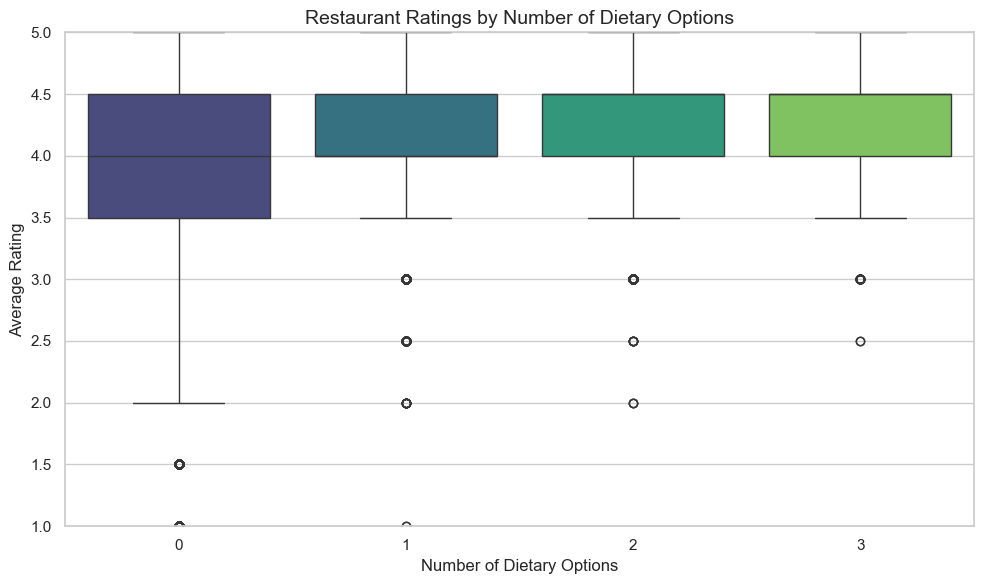

dietary_options_count
0   3.86
1   4.10
2   4.24
3   4.33
Name: avg_rating, dtype: float64

In [ ]:
# Create a boxplot. 
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean,
    x="dietary_options_count",
    y="avg_rating",
    palette="viridis")
plt.title("Restaurant Ratings by Number of Dietary Options", fontsize=14)
plt.xlabel("Number of Dietary Options")
plt.ylabel("Average Rating")
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

# Show the average ratings for each type of diet.
df_clean.groupby("dietary_options_count")["avg_rating"].mean()

The box plot shows that restaurants offering a wider variety of dietary options tend to have slightly more concentrated rating distributions around higher values.

Restaurants without dietary options show greater variability in customer ratings, including lower minimum values. Conversely, restaurants offering multiple dietary alternatives appear to maintain more stable rating distributions, generally concentrated between 4.0 and 4.5.

Even so, some low outliers are observed in all groups, although they appear less extreme among restaurants with more dietary variety.

### Q2. Is there a relationship between a restaurant's price level and its popularity?

The following visualization explores the relationship between restaurant price categories and customer popularity.

The goal is to determine whether more expensive restaurants tend to attract more customers or if popularity is similarly distributed across different price ranges.

- How many restaurants belong to each segment?

C:\Users\romer\AppData\Local\Temp\ipykernel_166892\2401235357.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


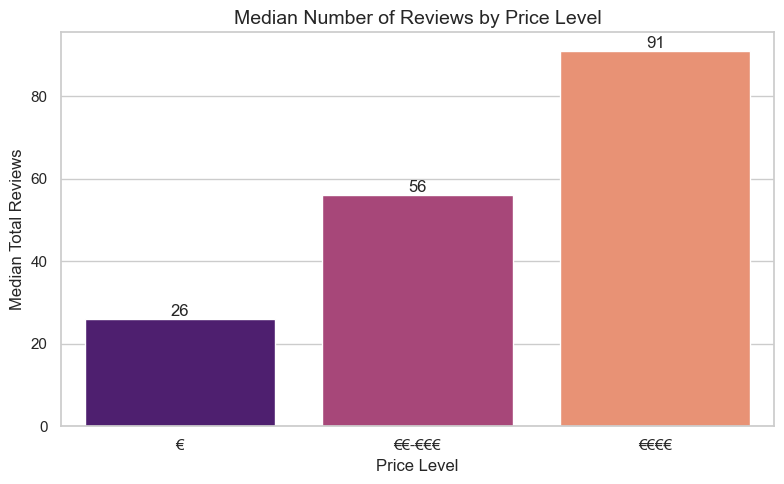

In [65]:
# Create a barplot
price_median = (df_clean.groupby("price_level")["total_reviews_count"].median().sort_values())

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=price_median.index,
    y=price_median.values,
    palette="magma")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Median Number of Reviews by Price Level", fontsize= 14)
plt.xlabel("Price Level")
plt.ylabel("Median Total Reviews")

plt.tight_layout()

plt.show()

The distribution shows a clear predominance of mid-range restaurants (€€-€€€) in the dataset, followed by low-range establishments (€). In contrast, there are far fewer high-end restaurants.

The results suggest that customer interaction patterns should be interpreted in conjunction with category size, given that larger restaurant groups exhibit greater diversity in popularity levels.

- How does popularity behave inside each segment?

C:\Users\romer\AppData\Local\Temp\ipykernel_166892\1950995729.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_clean,


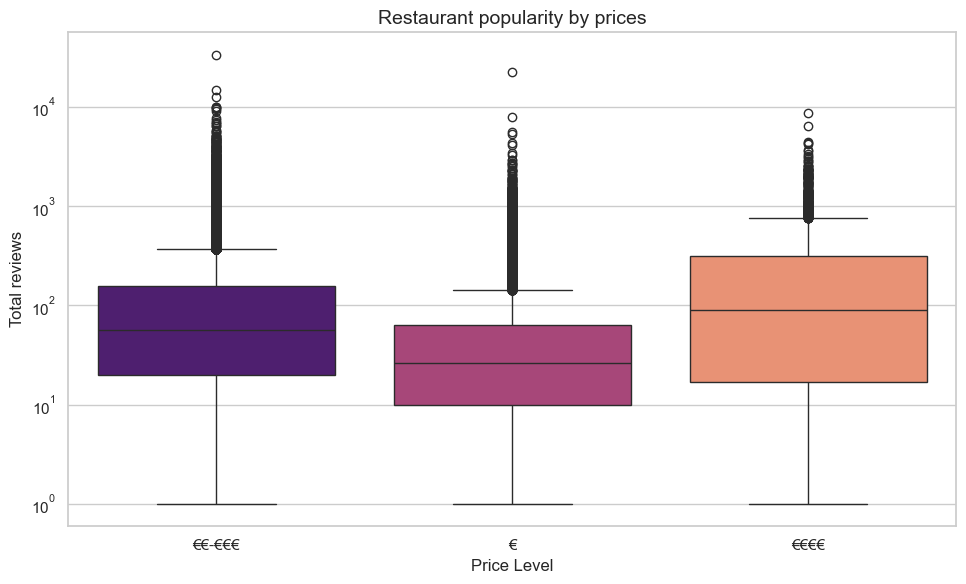

In [66]:
# Create a boxplot.
plt.figure(figsize=(10,6))

sns.boxplot(data = df_clean,
    x = "price_level",
    y = "total_reviews_count",
    palette = "magma")

plt.title("Restaurant popularity by prices", fontsize = 14)
plt.xlabel("Price Level")
plt.ylabel("Total reviews")

plt.tight_layout()
plt.yscale("log") # Use the log scale because the data are very different from each other.

plt.show()

The box plot reveals notable differences in customer interaction based on restaurant price categories.

More expensive restaurants tend to show a higher number of reviews, suggesting greater overall popularity and more customer interaction. However, this segment also exhibits significant variability, indicating that popularity among high-end restaurants is not uniform.
Lower- and mid-range restaurants show fewer reviews, although both groups contain numerous extreme outliers with very high popularity levels.

The visualization also shows significant skewness in review counts. This justifies the use of a logarithmic scale to improve interpretability.

### Q3. Which regions in Spain concentrate the highest-rated restaurants?

The following visualization compares the average restaurant ratings across the most represented Spanish regions in the dataset.

To ensure meaningful comparisons and reduce noise from underrepresented areas, the analysis focuses on the ten regions with the highest number of restaurants.

In [68]:
# Select the most representative regions.
top_regions = (df_clean["region"].value_counts().head(10).index)

# Create a filtered dataset only with top regions.
df_regions = df_clean[df_clean["region"].isin(top_regions)]

# Calculate mean ratings
region_ratings = (df_regions.groupby("region")["avg_rating"].mean().sort_values(ascending=False))

C:\Users\romer\AppData\Local\Temp\ipykernel_166892\1904593941.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


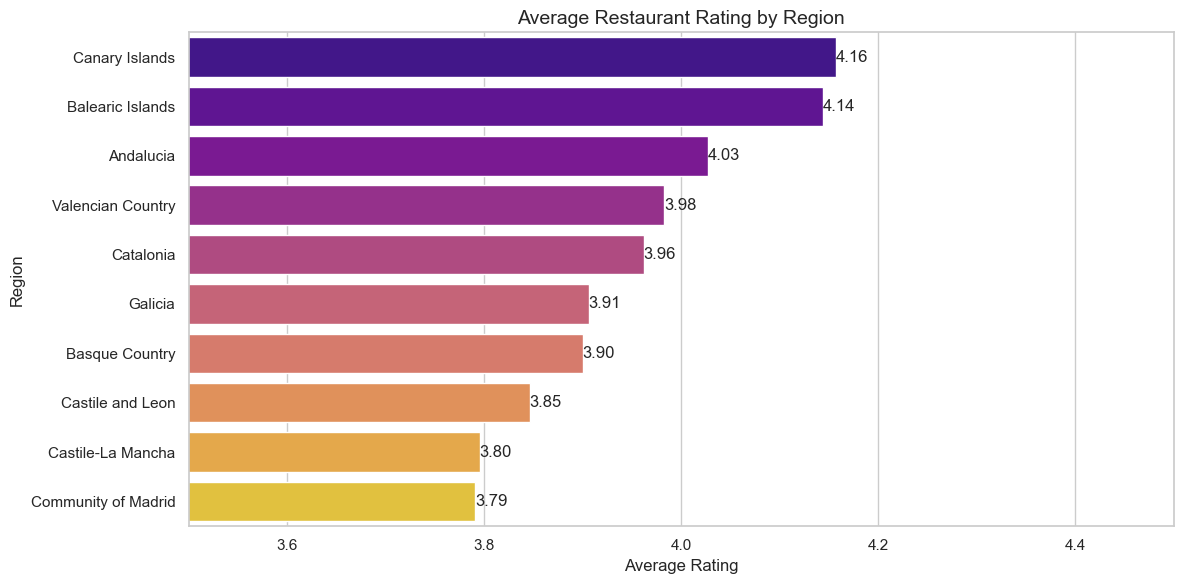

In [69]:
# Create a barplot
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x= region_ratings.values,
    y=region_ratings.index,
    palette="plasma")

# Add labels
for container in ax.containers:
    ax.bar_label(container,fmt="%.2f")

plt.title("Average Restaurant Rating by Region", fontsize=14)
plt.xlabel("Average Rating")
plt.ylabel("Region")

plt.tight_layout()
plt.xlim(3.5, 4.5)

plt.show()

We can see notable regional differences in restaurant ratings across Spain.

The Canary Islands and the Balearic Islands have the highest average scores, both exceeding 4.1 points. Andalusia also stands out for its relatively positive customer ratings compared to most of the mainland regions.

On the other hand, regions such as the Community of Madrid, Castilla-La Mancha, and Castilla y León have slightly lower average scores within the analyzed group.

Despite these differences, the overall variation between regions remains relatively moderate, with average scores concentrated within a fairly narrow range, between approximately 3.8 and 4.2. This suggests that the perception of restaurant quality in Spain tends to be generally positive and relatively consistent.

### Q4. Do restaurants that offer a wider variety of cuisines receive better customer ratings?

The following visualization explores the relationship between culinary diversity and restaurant ratings.

Culinary diversity is measured by the number of cuisine categories associated with each restaurant, allowing us to analyze whether restaurants that offer a wider variety of cuisines tend to achieve higher levels of customer satisfaction.

In [70]:
# Check how many restaurants there are in every segment.
df_clean["cuisine_count"].value_counts().sort_index()

cuisine_count
0     17218
1     40452
2     35006
3     24405
4     15042
5      7139
6      2482
7       660
8       148
9        57
10       29
11       20
12        8
13        1
14        1
Name: count, dtype: int64

We decide to create new labels until 6 or more because from 6 types of cuisines the number of restaurants per segment is greatly reduced. 

In [71]:
# Create a new grouped feature.
df_clean["cuisine_count_grouped"] = (df_clean["cuisine_count"].apply(lambda x: x if x <= 5 else 6))


In [72]:
# Create a 
group_counts = (df_clean["cuisine_count_grouped"].value_counts().sort_index())

labels = [f"{i if i < 6 else '6+'}\n({group_counts[i]})"for i in group_counts.index]

C:\Users\romer\AppData\Local\Temp\ipykernel_166892\2726070976.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean,


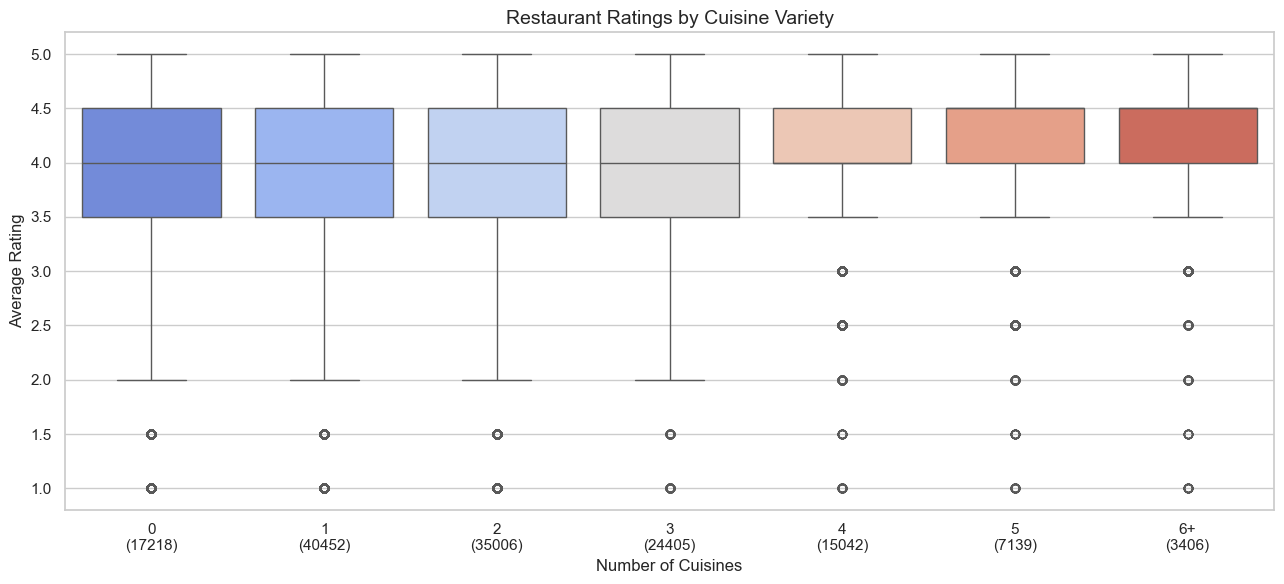

In [73]:
# Create a boxplot.
plt.figure(figsize=(13, 6))

sns.boxplot(data=df_clean,
    x="cuisine_count_grouped",
    y="avg_rating",
    palette="coolwarm")

plt.xticks(ticks=range(len(labels)),labels=labels)

plt.title("Restaurant Ratings by Cuisine Variety", fontsize=14)
plt.xlabel("Number of Cuisines")
plt.ylabel("Average Rating")

plt.tight_layout()

plt.show()

We can see a gradual increase in the consistency of ratings as the variety of cuisines grows.
Restaurants offering a wider range of cuisines generally have higher ratings, especially those with four or more cuisine categories. These groups show narrower interquartile ranges and fewer low-rating observations, indicating more stable customer satisfaction levels.
Conversely, restaurants with fewer cuisine categories (between zero and three) show greater variability in ratings, including lower minimum values ​​and wider overall distributions.

Despite these differences, median ratings remain relatively similar across all groups, generally centered around a value of 4.0. This suggests that cuisine variety alone does not drastically alter customer satisfaction, although greater cuisine diversity appears to be associated with slightly positive ratings.

The visualization also highlights a progressive reduction in sample size as cuisine variety increases, with restaurants offering six or more cuisine categories representing a comparatively smaller segment of the dataset.

### Q5. Do claimed restaurants receive better customer ratings?

The following visualization compares customer rating distributions between restaurants that actively manage their Tripadvisor profiles (“Claimed”) and those that do not (“Unclaimed”).

The objective is to explore whether profile management and platform presence are associated with differences in customer satisfaction levels.

In [74]:
# Create labels
claim_counts = (df_clean["claimed"].value_counts())

labels = [f"{label}\n({claim_counts[label]})"for label in claim_counts.index]

C:\Users\romer\AppData\Local\Temp\ipykernel_166892\4253048936.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean,


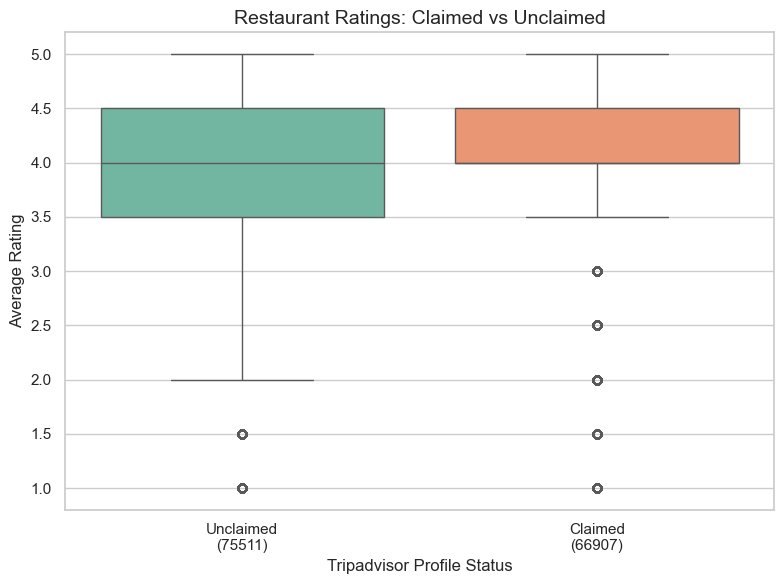

In [75]:
# Create a boxplot cause is a categorical variable.
plt.figure(figsize=(8, 6))

sns.boxplot(data=df_clean,
    x="claimed",
    y="avg_rating",
    palette="Set2")

plt.xticks(
    ticks=range(len(labels)),
    labels=labels)

plt.title("Restaurant Ratings: Claimed vs Unclaimed", fontsize=14)
plt.xlabel("Tripadvisor Profile Status")
plt.ylabel("Average Rating")

plt.tight_layout()

plt.show()

The visualization shows relatively similar rating distributions between restaurants with and without a TripAdvisor profile, with satisfied customers in both groups, averaging around 4.0.

However, restaurants with a TripAdvisor profile exhibit rating distributions more concentrated between 4.0 and 4.5, suggesting greater consistency in customer satisfaction levels.

Both categories show low outliers, although negative outliers appear to be slightly more frequent among restaurants with a TripAdvisor profile. This could reflect the greater visibility and customer exposure of actively managed establishments.

Overall, the results suggest a moderate association between TripAdvisor profile management and more consistent, positive customer reviews, although the differences remain relatively small.

# 8. Final Conclusions

The objective of this exploratory analysis was to investigate customer satisfaction, popularity patterns, and restaurant characteristics within the Spanish restaurant ecosystem using TripAdvisor data.


## Business Insights

1. Restaurants offering a wider variety of dietary options generally showed more stable and consistently positive customer ratings, suggesting a possible association between dietary inclusion and customer satisfaction.

2. More expensive restaurants achieved higher average popularity levels, as measured by customer reviews. However, extreme outliers were observed across all price categories, indicating that highly popular restaurants exist in all market segments.

3. Geographic analysis revealed moderate regional differences in restaurant ratings. The Canary Islands and the Balearic Islands had the highest ratings.

4. Restaurants offering greater culinary diversity seemed to maintain higher ratings, although culinary variety alone did not drastically alter customer ratings.

5. Verified Tripadvisor profiles showed slightly more stable and concentrated rating distributions compared to unverified establishments, suggesting a possible relationship between platform management and the consistency of customer perception. However, this relationship is very subtle.

## Limitations

When interpreting the results, several limitations should be considered:

- The dataset contains missing values ​​for multiple variables, particularly in the descriptive and operational information for the restaurants. It was decided to retain these values ​​to avoid losing relevant information and to maintain data consistency as much as possible.

- Ratings and the number of reviews may be influenced by external factors not included in the dataset, such as tourism intensity, restaurant age, marketing strategies, or local competition.

## Final Reflection

Overall, the analysis reveals that restaurant success and customer satisfaction within the Spanish restaurant ecosystem cannot be explained by a single factor. Price, culinary diversity, dietary options, and presence on digital platforms all appear to contribute—to varying degrees—to customer perception and interaction.